
# Vertrieb-Reporting – Delta-Demo (Sach & Leben)

Dieses Notebook erzeugt **synthetische Beispiel-Daten** für **Vorwoche** und **Folgewoche** in den Bereichen **Sach** und **Leben**.  
Anschließend werden **Deltas** berechnet und mehrere **Visualisierungen** gezeigt.

Enthaltene Plots:
1. **Pro Vermittler**: sortiertes Bar-Chart der Deltas je Produkt
2. **Heatmap**: Vermittler × Produkt
3. **Top/Flop Vermittler** + **Pareto** der Produkte
4. **Boxplot**: Verteilung der Deltas je Produkt

> Alle Daten in diesem Notebook sind **Dummy-Daten**.



## 0) Imports und Grundkonfiguration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.dpi"] = 120



## 1) Hilfsfunktionen

### `compute_delta(...)`
Berechnet für jede Kennzahl:

\[
\Delta = \text{Folgewoche} - \text{Vorwoche}
\]

Die Funktion ist robust gegenüber:
- neuen Vermittlern,
- weggefallenen Vermittlern,
- neuen Produkten/Spalten,
- fehlenden Werten.


In [2]:
def compute_delta(df_prev: pd.DataFrame, df_next: pd.DataFrame, id_col: str, metric_cols: list[str]) -> pd.DataFrame:
    """
    Robuste Delta-Berechnung (Folgewoche - Vorwoche).

    metric_cols darf Spalten enthalten, die nur in einer der beiden Wochen vorkommen.
    Fehlende Spalten werden automatisch mit 0 ergänzt.
    """
    a = df_prev.set_index(id_col).copy()
    b = df_next.set_index(id_col).copy()

    # nur gewünschte Kennzahlen; fehlende Spalten -> 0
    a = a.reindex(columns=metric_cols, fill_value=0)
    b = b.reindex(columns=metric_cols, fill_value=0)

    # numerisch erzwingen
    a = a.apply(pd.to_numeric, errors="coerce").fillna(0)
    b = b.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Vermittler (Index) ausrichten
    a2, b2 = a.align(b, join="outer", axis=0, fill_value=0)

    # Spalten ausrichten
    a2, b2 = a2.align(b2, join="outer", axis=1, fill_value=0)

    delta = b2.subtract(a2)
    return delta.reset_index()


def to_long(delta_df: pd.DataFrame, id_col: str) -> pd.DataFrame:
    """
    Wide -> Long.
    Beispiel:
    vermittler | SV_Hausrat | SV_BU
    ->
    vermittler | produkt    | delta
    """
    return delta_df.melt(
        id_vars=[id_col],
        var_name="produkt",
        value_name="delta"
    )


def missing_columns_report(df_prev: pd.DataFrame, df_next: pd.DataFrame, prefix: str):
    """Gibt aus, welche Kennzahlspalten nur in einer Woche vorkommen."""
    prev_cols = {c for c in df_prev.columns if c.startswith(prefix)}
    next_cols = {c for c in df_next.columns if c.startswith(prefix)}

    only_prev = sorted(prev_cols - next_cols)
    only_next = sorted(next_cols - prev_cols)

    print(f"--- Spalten-Check für Prefix {prefix} ---")
    print("Nur in Vorwoche:", only_prev if only_prev else "keine")
    print("Nur in Folgewoche:", only_next if only_next else "keine")



## 2) Dummy-Daten erzeugen

Wir simulieren:
- **Sach** mit `SV_*`-Produkten
- **Leben** mit `LV_*`-Produkten

Außerdem bauen wir bewusst Unterschiede ein:
- neue Vermittler in der Folgewoche,
- weggefallene Vermittler,
- neue oder fehlende Produkte.


In [3]:
# --- Dummy-Parameter ---
n_sach_prev, n_sach_next = 35, 40
n_leben_prev, n_leben_next = 25, 22

sach_products_prev = ["SV_Hausrat", "SV_Unfall", "SV_BU", "SV_KFZ", "SV_Haftpflicht"]
sach_products_next = sach_products_prev + ["SV_Rechtsschutz"]

leben_products_prev = ["LV_Risiko_A", "LV_Risiko_B", "LV_Risiko_C", "LV_Rente"]
leben_products_next = ["LV_Risiko_A", "LV_Risiko_B", "LV_Risiko_C"]

sach_prev_ids = np.arange(1001, 1001 + n_sach_prev)
sach_next_ids = np.arange(1008, 1008 + n_sach_next)

leben_prev_ids = np.arange(2001, 2001 + n_leben_prev)
leben_next_ids = np.arange(2005, 2005 + n_leben_next)

def make_week_df(ids, id_col, products, lam=2.0, spike_prob=0.08, spike_scale=12):
    """Erzeugt zählartige Dummy-Absatzzahlen mit gelegentlichen Ausreißern."""
    base = np.random.poisson(lam=lam, size=(len(ids), len(products))).astype(float)
    spikes = (np.random.rand(*base.shape) < spike_prob) * np.random.randint(0, spike_scale, size=base.shape)
    data = base + spikes
    df = pd.DataFrame(data, columns=products)
    df.insert(0, id_col, ids)
    return df

df_sach_prev = make_week_df(sach_prev_ids, "vermittler_sach", sach_products_prev, lam=2.2)
df_sach_next = make_week_df(sach_next_ids, "vermittler_sach", sach_products_next, lam=2.4)

df_leben_prev = make_week_df(leben_prev_ids, "vermittler_leben", leben_products_prev, lam=1.4)
df_leben_next = make_week_df(leben_next_ids, "vermittler_leben", leben_products_next, lam=1.5)

print("Sach Vorwoche:", df_sach_prev.shape)
print("Sach Folgewoche:", df_sach_next.shape)
print("Leben Vorwoche:", df_leben_prev.shape)
print("Leben Folgewoche:", df_leben_next.shape)

display(df_sach_prev.head())
display(df_sach_next.head())
display(df_leben_prev.head())
display(df_leben_next.head())


Sach Vorwoche: (35, 6)
Sach Folgewoche: (40, 7)
Leben Vorwoche: (25, 5)
Leben Folgewoche: (22, 4)


,vermittler_sach,SV_Hausrat,SV_Unfall,SV_BU,SV_KFZ,SV_Haftpflicht
0,1001,4.0,8.0,3.0,3.0,1.0
1,1002,2.0,1.0,1.0,2.0,2.0
2,1003,1.0,0.0,4.0,2.0,1.0
3,1004,3.0,2.0,6.0,1.0,2.0
4,1005,2.0,1.0,1.0,3.0,6.0


,vermittler_sach,SV_Hausrat,SV_Unfall,SV_BU,SV_KFZ,SV_Haftpflicht,SV_Rechtsschutz
0,1008,2.0,3.0,1.0,2.0,3.0,2.0
1,1009,3.0,2.0,0.0,2.0,0.0,1.0
2,1010,1.0,1.0,2.0,1.0,5.0,2.0
3,1011,0.0,1.0,2.0,3.0,2.0,3.0
4,1012,3.0,5.0,3.0,3.0,1.0,0.0


,vermittler_leben,LV_Risiko_A,LV_Risiko_B,LV_Risiko_C,LV_Rente
0,2001,1.0,2.0,0.0,1.0
1,2002,1.0,2.0,0.0,3.0
2,2003,3.0,0.0,2.0,1.0
3,2004,2.0,2.0,1.0,3.0
4,2005,2.0,0.0,2.0,2.0


,vermittler_leben,LV_Risiko_A,LV_Risiko_B,LV_Risiko_C
0,2005,3.0,2.0,1.0
1,2006,2.0,2.0,3.0
2,2007,2.0,8.0,3.0
3,2008,3.0,3.0,1.0
4,2009,0.0,1.0,1.0



## 3) Kennzahlspalten bestimmen und Delta berechnen


In [4]:
# Kennzahlspalten bestimmen
sach_metric_cols_prev = [c for c in df_sach_prev.columns if c.startswith("SV_")]
sach_metric_cols_next = [c for c in df_sach_next.columns if c.startswith("SV_")]
sach_metric_cols_all = sorted(set(sach_metric_cols_prev) | set(sach_metric_cols_next))

leben_metric_cols_prev = [c for c in df_leben_prev.columns if c.startswith("LV_")]
leben_metric_cols_next = [c for c in df_leben_next.columns if c.startswith("LV_")]
leben_metric_cols_all = sorted(set(leben_metric_cols_prev) | set(leben_metric_cols_next))

missing_columns_report(df_sach_prev, df_sach_next, "SV_")
missing_columns_report(df_leben_prev, df_leben_next, "LV_")

delta_sach = compute_delta(df_sach_prev, df_sach_next, "vermittler_sach", sach_metric_cols_all)
delta_leben = compute_delta(df_leben_prev, df_leben_next, "vermittler_leben", leben_metric_cols_all)

delta_sach_long = to_long(delta_sach, "vermittler_sach")
delta_leben_long = to_long(delta_leben, "vermittler_leben")

# Sicherheit: delta numerisch machen
delta_sach_long["delta"] = pd.to_numeric(delta_sach_long["delta"], errors="coerce").fillna(0)
delta_leben_long["delta"] = pd.to_numeric(delta_leben_long["delta"], errors="coerce").fillna(0)

print("delta_sach:", delta_sach.shape)
print("delta_sach_long:", delta_sach_long.shape)
print("delta_leben:", delta_leben.shape)
print("delta_leben_long:", delta_leben_long.shape)

display(delta_sach.head())
display(delta_sach_long.head(10))
display(delta_leben.head())
display(delta_leben_long.head(10))


--- Spalten-Check für Prefix SV_ ---
Nur in Vorwoche: keine
Nur in Folgewoche: ['SV_Rechtsschutz']
--- Spalten-Check für Prefix LV_ ---
Nur in Vorwoche: ['LV_Rente']
Nur in Folgewoche: keine
delta_sach: (47, 7)
delta_sach_long: (282, 3)
delta_leben: (26, 5)
delta_leben_long: (104, 3)


,vermittler_sach,SV_BU,SV_Haftpflicht,SV_Hausrat,SV_KFZ,SV_Rechtsschutz,SV_Unfall
0,1001,-3.0,-1.0,-4.0,-3.0,0.0,-8.0
1,1002,-1.0,-2.0,-2.0,-2.0,0.0,-1.0
2,1003,-4.0,-1.0,-1.0,-2.0,0.0,0.0
3,1004,-6.0,-2.0,-3.0,-1.0,0.0,-2.0
4,1005,-1.0,-6.0,-2.0,-3.0,0.0,-1.0


,vermittler_sach,produkt,delta
0,1001,SV_BU,-3.0
1,1002,SV_BU,-1.0
2,1003,SV_BU,-4.0
3,1004,SV_BU,-6.0
4,1005,SV_BU,-1.0
5,1006,SV_BU,-1.0
6,1007,SV_BU,0.0
7,1008,SV_BU,-14.0
8,1009,SV_BU,-2.0
9,1010,SV_BU,0.0


,vermittler_leben,LV_Rente,LV_Risiko_A,LV_Risiko_B,LV_Risiko_C
0,2001,-1.0,-1.0,-2.0,0.0
1,2002,-3.0,-1.0,-2.0,0.0
2,2003,-1.0,-3.0,0.0,-2.0
3,2004,-3.0,-2.0,-2.0,-1.0
4,2005,-2.0,1.0,2.0,-1.0


,vermittler_leben,produkt,delta
0,2001,LV_Rente,-1.0
1,2002,LV_Rente,-3.0
2,2003,LV_Rente,-1.0
3,2004,LV_Rente,-3.0
4,2005,LV_Rente,-2.0
5,2006,LV_Rente,-2.0
6,2007,LV_Rente,-11.0
7,2008,LV_Rente,-1.0
8,2009,LV_Rente,-2.0
9,2010,LV_Rente,-5.0



## 4) Plot 1 – Pro Vermittler: Delta je Produkt (sortiertes Bar-Chart)


Demo-Vermittler Sach: 1030
Demo-Vermittler Leben: 2015


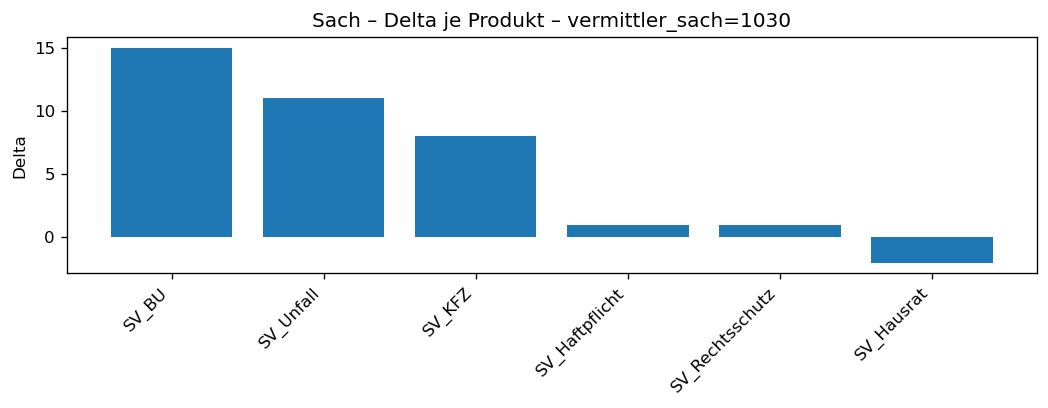

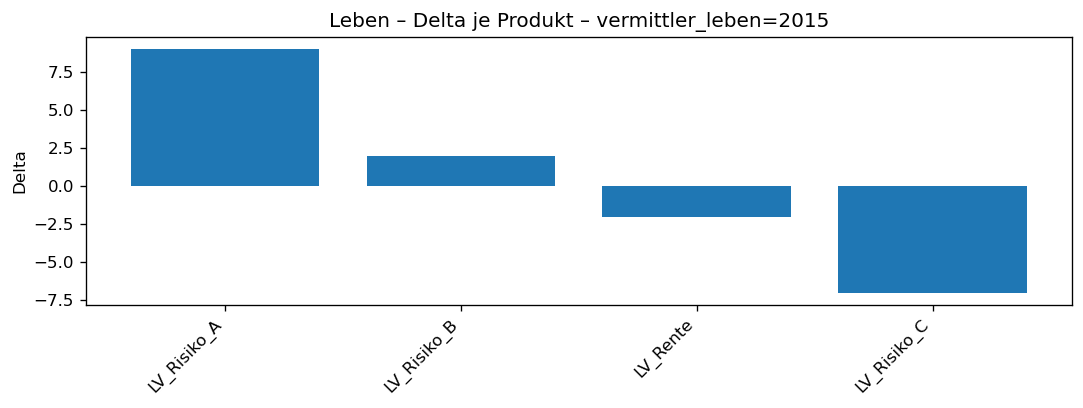

In [5]:
def pick_demo_broker(delta_long: pd.DataFrame, id_col: str):
    """Wählt den Vermittler mit der größten absoluten Gesamtbewegung."""
    required_cols = [id_col, "produkt", "delta"]
    missing = [c for c in required_cols if c not in delta_long.columns]
    if missing:
        raise KeyError(f"Fehlende Spalten: {missing}")

    df = delta_long[required_cols].copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)
    df = df.dropna(subset=[id_col])

    if df.empty:
        raise ValueError(f"{id_col}: Keine Daten vorhanden.")

    score = df.assign(delta_abs=df["delta"].abs()).groupby(id_col)["delta_abs"].sum()

    if score.empty:
        raise ValueError(f"{id_col}: Keine Vermittler-Scores vorhanden.")

    return score.sort_values(ascending=False).index[0]


def plot_broker_bars(delta_long: pd.DataFrame, id_col: str, broker_id, top_n: int = 20, title_prefix: str = ""):
    required_cols = [id_col, "produkt", "delta"]
    missing = [c for c in required_cols if c not in delta_long.columns]
    if missing:
        raise KeyError(f"Fehlende Spalten: {missing}")

    df = delta_long[required_cols].copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)

    df_b = df[df[id_col] == broker_id].copy()

    if df_b.empty:
        raise ValueError(f"Vermittler {broker_id} nicht in {id_col} gefunden.")

    df_b = df_b.sort_values("delta", ascending=False).head(top_n)

    plt.figure(figsize=(9, 3.5))
    plt.bar(df_b["produkt"], df_b["delta"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Delta")
    plt.title(f"{title_prefix}Delta je Produkt – {id_col}={broker_id}")
    plt.tight_layout()
    plt.show()

demo_broker_sach = pick_demo_broker(delta_sach_long, "vermittler_sach")
demo_broker_leben = pick_demo_broker(delta_leben_long, "vermittler_leben")

print("Demo-Vermittler Sach:", demo_broker_sach)
print("Demo-Vermittler Leben:", demo_broker_leben)

plot_broker_bars(delta_sach_long, "vermittler_sach", demo_broker_sach, top_n=12, title_prefix="Sach – ")
plot_broker_bars(delta_leben_long, "vermittler_leben", demo_broker_leben, top_n=10, title_prefix="Leben – ")


### Interpretation: Delta je Produkt für einen Vermittler

Dieser Plot zeigt für einen ausgewählten Vermittler die Veränderung der Absatzzahlen zwischen Folgewoche und Vorwoche, aufgeschlüsselt nach Produkten bzw. Sparten.

- **Positive Werte** bedeuten einen Zuwachs in der Folgewoche.
- **Negative Werte** bedeuten einen Rückgang gegenüber der Vorwoche.
- Durch die Sortierung wird unmittelbar sichtbar, welche Produkte die stärksten Anstiege bzw. Rückgänge aufweisen.

Die Darstellung eignet sich besonders für die Einzelfallanalyse, da sie schnell erkennen lässt, in welchen Bereichen ein Vermittler aktuell auffällig positiv oder negativ vom Vorwochenwert abweicht.


## 5) Plot 2 – Heatmap: Vermittler × Produkt (Delta)


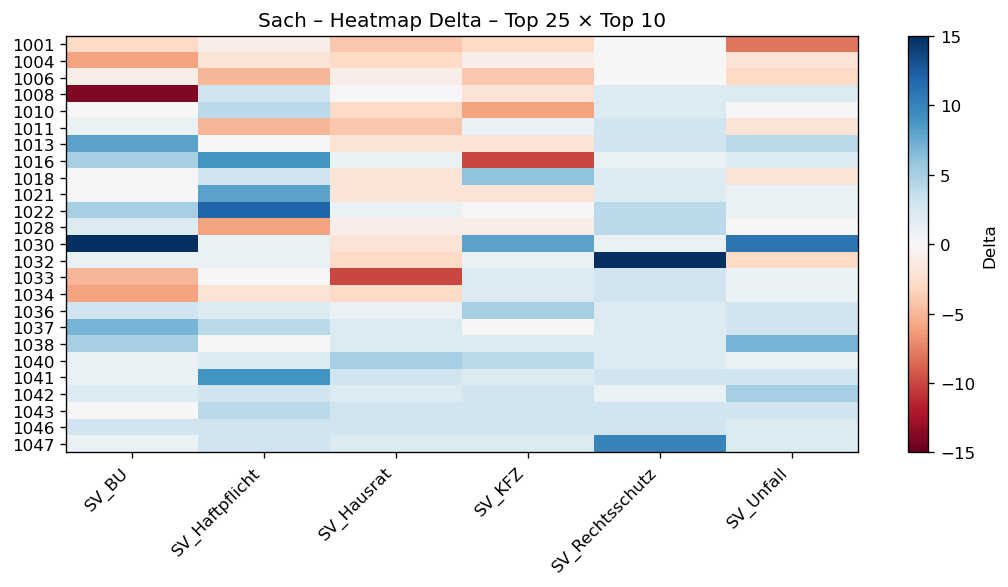

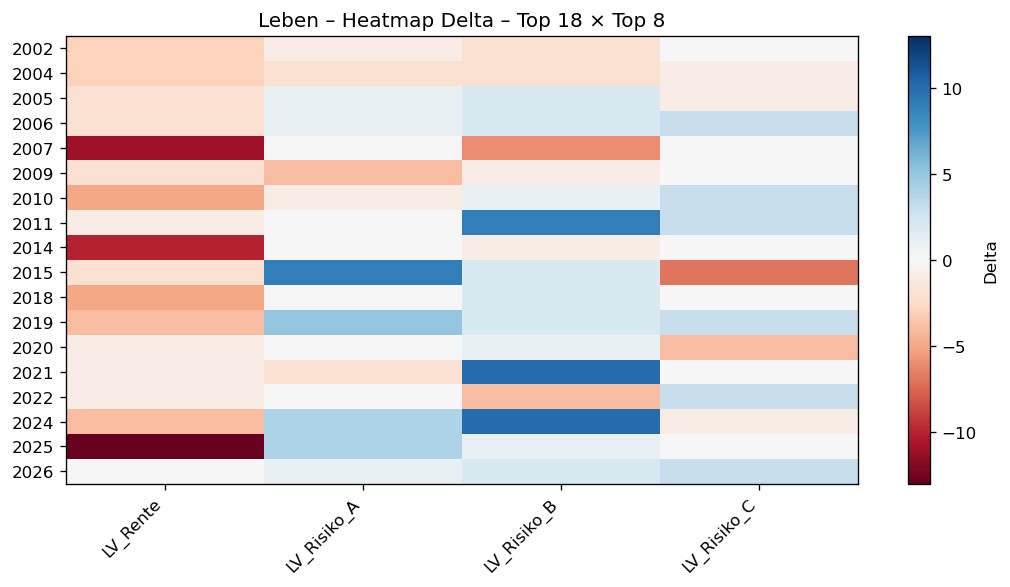

In [13]:
def plot_heatmap(delta_long: pd.DataFrame, id_col: str, top_products: int = 12, top_brokers: int = 30, title_prefix: str = ""):
    df = delta_long[[id_col, "produkt", "delta"]].copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)
    df = df.dropna(subset=[id_col])

    prod_rank = (
        df.groupby("produkt")["delta"]
        .apply(lambda s: s.abs().sum())
        .sort_values(ascending=False)
    )
    top_prods = prod_rank.head(top_products).index

    broker_rank = (
        df.groupby(id_col)["delta"]
        .apply(lambda s: s.abs().sum())
        .sort_values(ascending=False)
    )
    top_ids = broker_rank.head(top_brokers).index

    m = df[df["produkt"].isin(top_prods) & df[id_col].isin(top_ids)]
    pivot = m.pivot(index=id_col, columns="produkt", values="delta").fillna(0)

    max_abs = np.abs(pivot.values).max()

    plt.figure(figsize=(9, 5))
    #plt.imshow(pivot.values, aspect="auto", cmap="bwr", vmin=-max_abs, vmax=max_abs)
    plt.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-max_abs, vmax=max_abs)
    plt.colorbar(label="Delta")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(f"{title_prefix}Heatmap Delta – Top {top_brokers} × Top {top_products}")
    plt.tight_layout()
    plt.show()

plot_heatmap(delta_sach_long, "vermittler_sach", top_products=10, top_brokers=25, title_prefix="Sach – ")
plot_heatmap(delta_leben_long, "vermittler_leben", top_products=8, top_brokers=18, title_prefix="Leben – ")


### Hinweis zur Farbwahl der Heatmap

Da die Heatmap Deltas darstellt, also positive und negative Veränderungen relativ zu einem Nullpunkt, ist eine **divergierende Farbskala** fachlich besonders geeignet. Eine Skala von **blau über weiß nach rot** erlaubt es, positive, neutrale und negative Werte klar voneinander zu unterscheiden.

- **Blau** steht für positive Veränderungen,
- **Weiß** für Werte nahe null,
- **Rot** für negative Veränderungen.

Damit wird nicht nur die Stärke, sondern auch die **Richtung** der Veränderung unmittelbar sichtbar. Für Delta-Analysen ist dies in der Regel aussagekräftiger als eine rein sequentielle Farbskala.

### Interpretation: Heatmap der Deltas über Vermittler und Produkte

Die Heatmap visualisiert die Deltas gleichzeitig über mehrere Vermittler und Produkte hinweg. Jede Zelle steht für die Veränderung eines Produkts bei einem Vermittler.

- **Stärkere Farbintensitäten** markieren größere Veränderungen.
- Dadurch lassen sich Muster schnell erkennen, etwa:
  - Produkte mit generell hoher Bewegung,
  - Vermittler mit auffälligen Ausschlägen,
  - Konzentrationen von Veränderungen in bestimmten Produktgruppen.

Die Heatmap ist besonders hilfreich, um nicht nur Einzelfälle, sondern die Struktur der Veränderungen im gesamten Kollektiv zu betrachten.


## 6) Plot 3 – Top/Flop Vermittler + Pareto der Produkte


TOP 10 – vermittler_sach
vermittler_sach
1030    34.0
1022    23.0
1041    21.0
1047    20.0
1038    18.0
1037    18.0
1046    17.0
1042    16.0
1043    16.0
1036    16.0

FLOP 10 – vermittler_sach
vermittler_sach
1007    -5.0
1011    -6.0
1002    -8.0
1003    -8.0
1033    -9.0
1008    -9.0
1005   -13.0
1006   -14.0
1004   -14.0
1001   -19.0


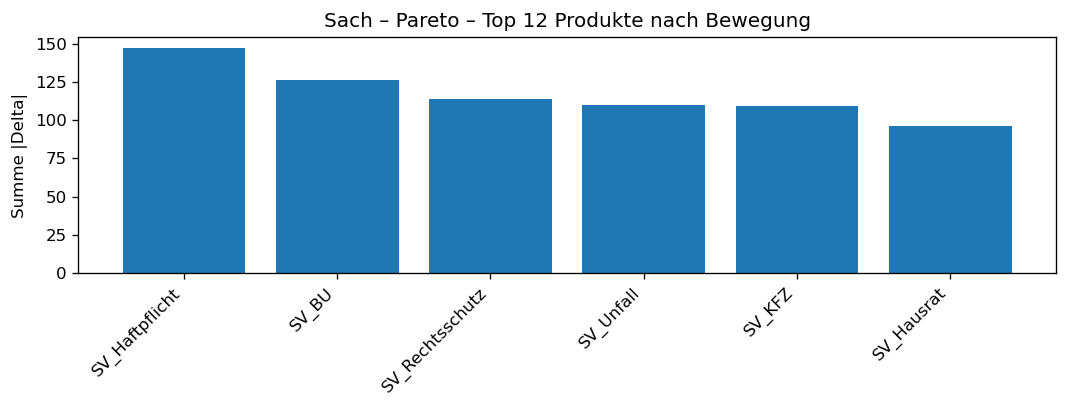

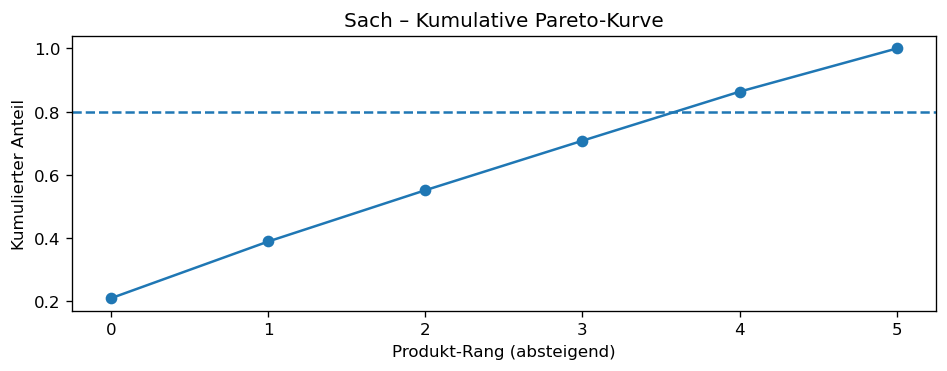

TOP 8 – vermittler_leben
vermittler_leben
2011    11.0
2024     9.0
2021     7.0
2019     6.0
2026     6.0
2006     4.0
2008     2.0
2015     2.0

FLOP 8 – vermittler_leben
vermittler_leben
2016    -4.0
2002    -6.0
2003    -6.0
2009    -7.0
2004    -8.0
2025    -8.0
2014   -11.0
2007   -17.0


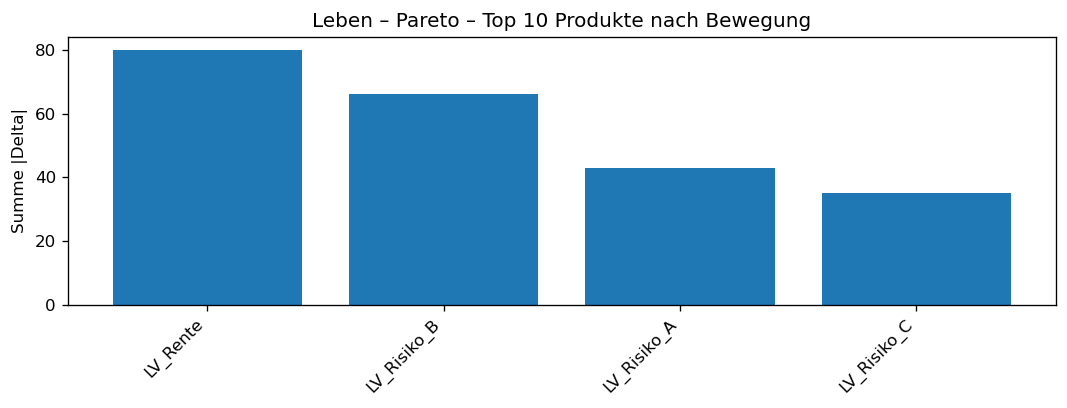

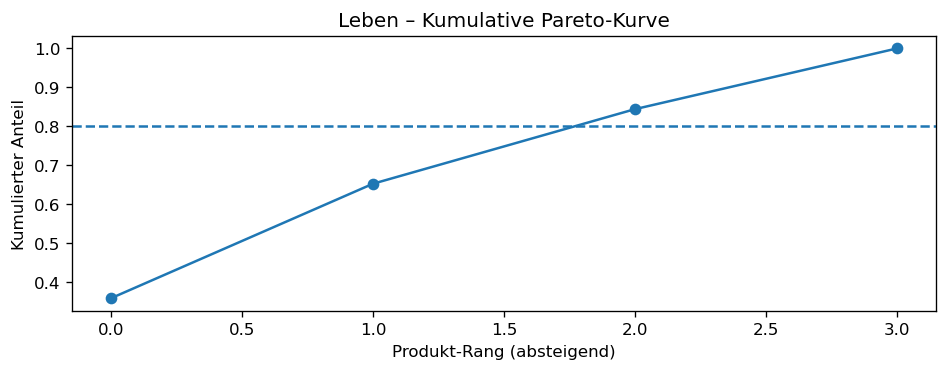

In [7]:
def print_top_flop(delta_wide: pd.DataFrame, id_col: str, n: int = 10):
    total = delta_wide.set_index(id_col).sum(axis=1).sort_values(ascending=False)

    print(f"TOP {n} – {id_col}")
    print(total.head(n).to_string())

    print(f"\nFLOP {n} – {id_col}")
    print(total.tail(n).to_string())

    return total


def plot_pareto(delta_long: pd.DataFrame, title_prefix: str = "", top_k: int = 20):
    df = delta_long[["produkt", "delta"]].copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)

    prod_abs = (
        df.groupby("produkt")["delta"]
        .apply(lambda s: s.abs().sum())
        .sort_values(ascending=False)
    )

    pareto = prod_abs.reset_index(name="abs_movement")
    pareto["cum_share"] = pareto["abs_movement"].cumsum() / pareto["abs_movement"].sum()

    top = pareto.head(top_k)

    plt.figure(figsize=(9, 3.5))
    plt.bar(top["produkt"], top["abs_movement"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Summe |Delta|")
    plt.title(f"{title_prefix}Pareto – Top {top_k} Produkte nach Bewegung")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3.2))
    plt.plot(pareto["cum_share"].values, marker="o")
    plt.axhline(0.8, linestyle="--")
    plt.xlabel("Produkt-Rang (absteigend)")
    plt.ylabel("Kumulierter Anteil")
    plt.title(f"{title_prefix}Kumulative Pareto-Kurve")
    plt.tight_layout()
    plt.show()

_ = print_top_flop(delta_sach, "vermittler_sach", n=10)
plot_pareto(delta_sach_long, title_prefix="Sach – ", top_k=12)

_ = print_top_flop(delta_leben, "vermittler_leben", n=8)
plot_pareto(delta_leben_long, title_prefix="Leben – ", top_k=10)


### Interpretation: Top- und Flop-Vermittler nach Gesamtdelta

Diese Auswertung aggregiert die Deltas über alle Produkte je Vermittler und ordnet die Vermittler nach ihrer gesamten Veränderung zwischen Vorwoche und Folgewoche.

- **Top-Vermittler** weisen die größten positiven Gesamtveränderungen auf.
- **Flop-Vermittler** zeigen die stärksten negativen Gesamtveränderungen.

Die Auswertung dient einer schnellen verdichteten Einordnung auf Vermittlerebene und eignet sich besonders für vertriebliche Steuerungsfragen, etwa zur Identifikation besonders positiver Entwicklungen oder auffälliger Rückgänge.

### Interpretation: Pareto-Analyse der Produktbewegungen

Die Pareto-Darstellung zeigt, welche Produkte den größten Anteil an der gesamten absoluten Veränderung tragen.

- Zunächst werden die Produkte nach ihrer gesamten Bewegungsstärke sortiert.
- Anschließend wird der kumulierte Anteil an der Gesamtbewegung dargestellt.

So lässt sich erkennen, ob sich die Veränderungen auf wenige zentrale Produkte konzentrieren oder ob sie breiter über viele Produkte verteilt sind. Die Analyse unterstützt damit die Priorisierung: Produkte mit hohem Beitrag zur Gesamtbewegung verdienen in der Regel besondere Aufmerksamkeit.

---
### Pareto-Prinzip und Bezug zur Pareto-Kurve

Der Begriff **Pareto** geht auf den Ökonomen **Vilfredo Pareto** zurück. Im analytischen Kontext ist damit meist das sogenannte **Pareto-Prinzip** gemeint, das häufig als **80/20-Regel** bezeichnet wird. Es beschreibt die Beobachtung, dass in vielen Zusammenhängen ein relativ kleiner Teil der Ursachen einen großen Teil der Wirkung erklärt.

Auf den vorliegenden Fall übertragen bedeutet das:

- Nicht alle Produkte tragen gleichermaßen zur gesamten Veränderung zwischen Vorwoche und Folgewoche bei.
- Häufig wird ein großer Teil der Gesamtbewegung bereits durch wenige Produkte verursacht.
- Die Pareto-Analyse hilft daher zu erkennen, **welche Produkte die Veränderungen hauptsächlich treiben**.

Für den Plot werden die Produkte zunächst nach ihrer **absoluten Bewegung** sortiert, also danach, wie stark sie insgesamt zur Veränderung beitragen, unabhängig davon, ob die Veränderung positiv oder negativ ist. Anschließend wird der **kumulierte Anteil** dieser Beiträge dargestellt.

Die Pareto-Kurve beantwortet damit insbesondere die Frage:

> Wie viele der wichtigsten Produkte sind nötig, um einen großen Teil der gesamten Veränderung zu erklären?

Liegt die Kurve früh bereits hoch, konzentriert sich die Bewegung auf wenige Produkte. Steigt sie dagegen langsamer an, verteilt sich die Veränderung breiter über viele Produkte.

---

### Erläuterung des dargestellten Beispiels der kumulativen Pareto-Kurve (Leben)

Die gezeigte Pareto-Kurve für den Bereich **Leben** veranschaulicht, wie sich die gesamte absolute Veränderung auf die nach Bewegungsstärke sortierten Produkte verteilt.

Im konkreten Beispiel zeigt der Verlauf:

- Bereits das **erstplatzierte Produkt** erklärt rund **36 %** der gesamten Bewegung.
- Die **zwei wichtigsten Produkte zusammen** erklären bereits etwa **65 %**.
- Mit dem **dritten Produkt** steigt der kumulierte Anteil auf ungefähr **85 %**.
- Spätestens mit dem **vierten Produkt** ist die gesamte Bewegung (**100 %**) erklärt.

Die gestrichelte Linie bei **0,8** markiert die typische **80-%-Schwelle** des Pareto-Prinzips. Da diese Schwelle hier bereits beim **dritten Produkt** überschritten wird, lässt sich das Ergebnis wie folgt interpretieren:

> Im vorliegenden Beispiel wird der überwiegende Teil der Veränderungen im Bereich Leben durch nur wenige Produkte getragen.

Das ist analytisch besonders nützlich, weil sich die Aufmerksamkeit damit auf die zentralen Treiber richten lässt. Anstatt alle Produkte gleich stark zu betrachten, kann die Analyse zunächst auf jene wenigen Produkte fokussiert werden, die den Großteil der Gesamtbewegung verursachen.


## 7) Plot 4 – Boxplot: Delta-Verteilung je Produkt


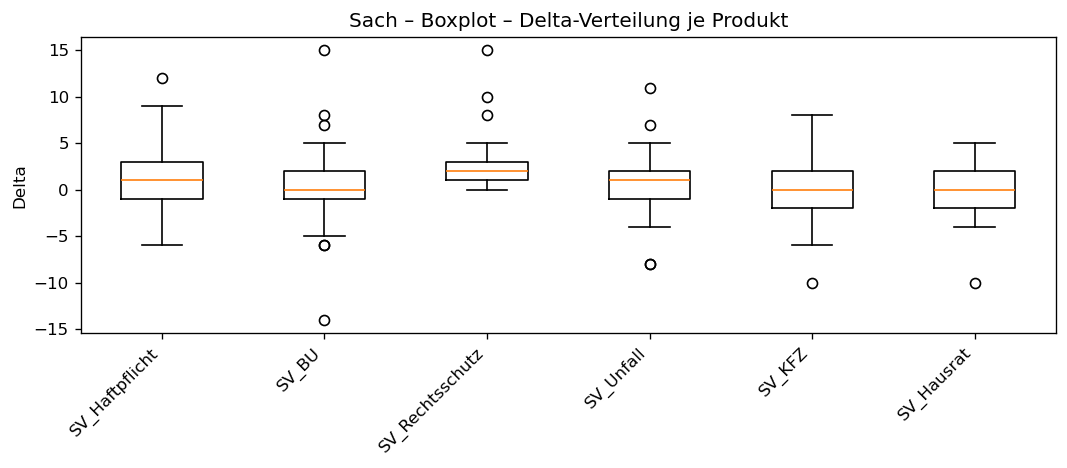

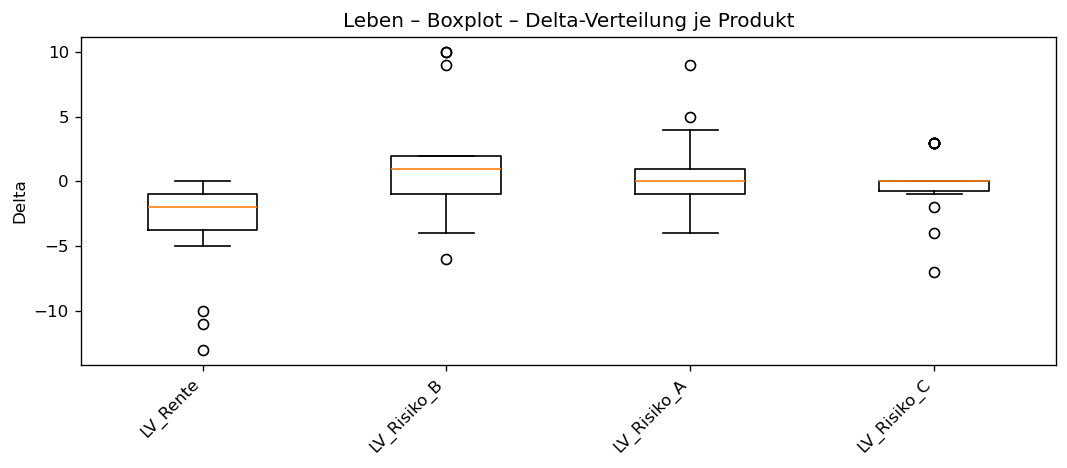

In [10]:
def plot_box_by_product(delta_long: pd.DataFrame, title_prefix: str = "", top_products: int = 12):
    df = delta_long[["produkt", "delta"]].copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)

    prod_rank = (
        df.groupby("produkt")["delta"]
        .apply(lambda s: s.abs().sum())
        .sort_values(ascending=False)
    )

    prods = list(prod_rank.head(top_products).index)
    data = [df[df["produkt"] == p]["delta"].values for p in prods]

    plt.figure(figsize=(9, 4))
    plt.boxplot(data, labels=prods)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Delta")
    plt.title(f"{title_prefix}Boxplot – Delta-Verteilung je Produkt")
    plt.tight_layout()
    plt.show()

plot_box_by_product(delta_sach_long, title_prefix="Sach – ", top_products=10)
plot_box_by_product(delta_leben_long, title_prefix="Leben – ", top_products=8)


### Interpretation: Verteilung der Deltas je Produkt

Der Boxplot zeigt für jedes Produkt die Verteilung der Deltas über alle Vermittler hinweg.

Dadurch werden mehrere Aspekte sichtbar:

- **Median**: typische zentrale Veränderung des Produkts,
- **Streuung**: wie stark die Vermittlerwerte auseinanderliegen,
- **Ausreißer**: einzelne Vermittler mit besonders starken positiven oder negativen Abweichungen.

Diese Darstellung ist besonders nützlich, um zu beurteilen, ob Veränderungen eher ein allgemeiner Trend im Kollektiv sind oder hauptsächlich von wenigen auffälligen Vermittlern getragen werden.

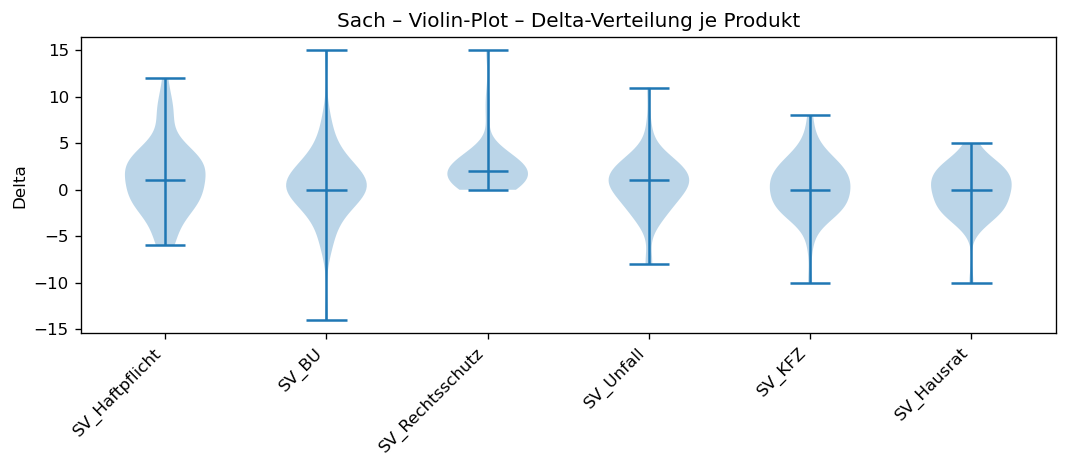

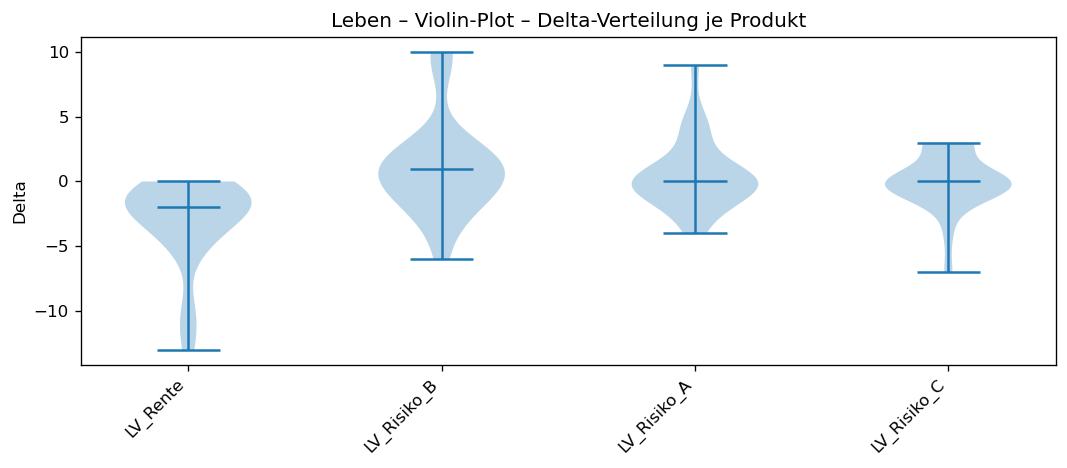

In [16]:
def plot_violin_by_product(delta_long: pd.DataFrame, title_prefix: str = "", top_products: int = 12):
    df = delta_long[["produkt", "delta"]].copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)

    prod_rank = (
        df.groupby("produkt")["delta"]
        .apply(lambda s: s.abs().sum())
        .sort_values(ascending=False)
    )

    prods = list(prod_rank.head(top_products).index)
    data = [df[df["produkt"] == p]["delta"].values for p in prods]

    plt.figure(figsize=(9, 4))
    plt.violinplot(data, showmeans=False, showmedians=True)
    plt.xticks(range(1, len(prods) + 1), prods, rotation=45, ha="right")
    plt.ylabel("Delta")
    plt.title(f"{title_prefix}Violin-Plot – Delta-Verteilung je Produkt")
    plt.tight_layout()
    plt.show()

plot_violin_by_product(delta_sach_long, title_prefix="Sach – ", top_products=10)
plot_violin_by_product(delta_leben_long, title_prefix="Leben – ", top_products=8)

### Boxplot versus Violin-Plot

Die Boxplots können alternativ auch als **Violin-Plots** dargestellt werden. Während der Boxplot vor allem kompakte Lage- und Streuungsmaße zeigt (Median, Quartile, Ausreißer), visualisiert der Violin-Plot zusätzlich die **Form der Verteilung**.

Dadurch kann besser erkannt werden,

- ob sich Werte stark um null konzentrieren,
- ob die Verteilung asymmetrisch ist,
- oder ob mehrere Häufungen innerhalb eines Produkts auftreten.

Für ein kompaktes Reporting sind Boxplots meist leichter lesbar. Für eine vertiefte Analyse der Delta-Strukturen können Violin-Plots jedoch einen zusätzlichen Erkenntnisgewinn bieten.


## 8) Optional: kleine Diagnose
Falls später bei Echtdaten etwas hakt, helfen diese Prüfungen oft sofort.


In [9]:
print("delta_sach_long.dtypes")
print(delta_sach_long.dtypes)
print("\n")
print("delta_leben_long.dtypes")
print(delta_leben_long.dtypes)

print("\nBeispiel delta_sach_long:")
display(delta_sach_long.head())

print("\nBeispiel delta_leben_long:")
display(delta_leben_long.head())


delta_sach_long.dtypes
vermittler_sach      int32
produkt             object
delta              float64
dtype: object


delta_leben_long.dtypes
vermittler_leben      int32
produkt              object
delta               float64
dtype: object

Beispiel delta_sach_long:


,vermittler_sach,produkt,delta
0,1001,SV_BU,-3.0
1,1002,SV_BU,-1.0
2,1003,SV_BU,-4.0
3,1004,SV_BU,-6.0
4,1005,SV_BU,-1.0



Beispiel delta_leben_long:


,vermittler_leben,produkt,delta
0,2001,LV_Rente,-1.0
1,2002,LV_Rente,-3.0
2,2003,LV_Rente,-1.0
3,2004,LV_Rente,-3.0
4,2005,LV_Rente,-2.0


## Visualisierung der Delta-Analysen

Zur besseren Interpretation der Veränderungen zwischen Vorwoche und Folgewoche werden die berechneten Deltas aus unterschiedlichen Perspektiven visualisiert. Dabei werden sowohl Einzelbetrachtungen auf Vermittlerebene als auch kollektive Muster über Produkte und Vermittler hinweg berücksichtigt.

---
---

In [17]:
import pandas as pd
import plotly.graph_objects as go

def build_broker_dropdown_chart(delta_long: pd.DataFrame, id_col: str, title: str = "Delta je Produkt"):
    df = delta_long.copy()
    df["delta"] = pd.to_numeric(df["delta"], errors="coerce").fillna(0)

    brokers = sorted(df[id_col].dropna().unique())

    fig = go.Figure()

    # Für jeden Vermittler ein Trace
    for i, broker in enumerate(brokers):
        df_b = df[df[id_col] == broker].copy()
        df_b = df_b.sort_values("delta", ascending=False)

        fig.add_trace(
            go.Bar(
                x=df_b["produkt"],
                y=df_b["delta"],
                name=str(broker),
                visible=(i == 0)
            )
        )

    # Dropdown-Buttons
    buttons = []
    for i, broker in enumerate(brokers):
        visible = [False] * len(brokers)
        visible[i] = True

        buttons.append(
            dict(
                label=str(broker),
                method="update",
                args=[
                    {"visible": visible},
                    {"title": f"{title} – Vermittler {broker}"}
                ]
            )
        )

    fig.update_layout(
        title=f"{title} – Vermittler {brokers[0]}",
        xaxis_title="Produkt",
        yaxis_title="Delta",
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.02,
                y=1.0
            )
        ]
    )

    return fig

In [18]:
fig = build_broker_dropdown_chart(delta_sach_long, "vermittler_sach", title="Sach – Delta je Produkt")
fig.write_html("sach_broker_dropdown.html")

In [19]:
fig = build_broker_dropdown_chart(delta_leben_long, "vermittler_leben", title="Leben – Delta je Produkt")
fig.write_html("leben_broker_dropdown.html")

### Interaktive Auswahl von Vermittlern

Für die Darstellung der produktbezogenen Deltas auf Vermittlerebene bietet sich eine interaktive Auswahl über ein Dropdown-Menü an. Technisch lässt sich dies beispielsweise mit Plotly umsetzen und als HTML-Datei exportieren. Dadurch kann im Browser jeweils ein Vermittler ausgewählt werden, ohne dass für jeden Fall eine separate Grafik erzeugt werden muss.

Eine solche Lösung ist insbesondere für Berichts- und Präsentationszwecke vorteilhaft, da sie eine kompakte, benutzerfreundliche Navigation durch die Vermittlerdaten erlaubt.

---
---

# Ergänzende Ideen:

## B) Streamlit als kleine Web-App

Hier wäre die Auswahl noch komfortabler:

- Dropdown
- Filter
- Tabs
- mehrere Grafiken gleichzeitig

Aber:

- das ist keine einfache statische HTML-Datei
- sondern eine kleine laufende App

Für den Vertrieb ist das oft langfristig die bessere Lösung, aber für einen ersten verteilbaren Prototyp ist Plotly-HTML oft ideal.

### Empfehlung

Für den Start:

- Plotly + HTML-Export, wenn ihr eine Datei wollt
- später Streamlit, wenn das Ganze regelmäßig genutzt werden soll

---

## 2) Weitere Auswertungen mit Mehrwert für den Vertrieb

Ja — einige sogar mit sehr praktischem Nutzen.

Die bisherigen Visualisierungen sind gut für Beschreibung. Was dem Vertrieb oft zusätzlich hilft, sind Auswertungen, die stärker in Richtung Priorisierung, Auffälligkeit und Steuerung gehen.

---

### A) Ampel-/Ranking-Ansicht je Vermittler

Zusätzlich zum Bar-Chart könnte man je Vermittler eine kleine Tabelle bauen:

- Top 5 gestiegene Produkte
- Top 5 gefallene Produkte
- Gesamtdelta
- Anteil positiver / negativer Produkte

Das ist sehr berichtstauglich.

#### Nutzen

Ein Vermittler sieht sofort:

- wo die größten Zugewinne liegen
- wo dringender Gesprächsbedarf besteht

---

### B) Abweichung vom Kollektiv

Nicht nur: „Wie hat sich Vermittler X verändert?“  
Sondern auch: „Wie stark weicht Vermittler X vom Durchschnitt aller Vermittler ab?“

#### Beispiel

- Produkt A: Kollektiv +1,2
- Vermittler X: -3

Dann ist X nicht nur negativ, sondern relativ auffällig negativ.

#### Visualisierung

- Barplot: Vermittler-Delta minus Kollektivmittel
- z-Score / standardisierte Abweichung
- Heatmap der Abweichungen statt der Rohdeltas

#### Nutzen

Das hilft dem Vertrieb stärker als reine Rohwerte, weil man sofort erkennt:

- normaler Wochenrauschen-Effekt
- oder echte Auffälligkeit

---

### C) Ausreißeranalyse

#### Frage

Welche Vermittler zeigen ungewöhnlich starke Veränderungen?

Das kann man produktweise oder gesamt machen.

#### Mögliche Verfahren

- z-Score
- IQR-Regel
- Abstand vom Median

#### Nutzen

- gezielte Vertriebsansprache
- schnelle Identifikation auffälliger Fälle
- potenziell Datenqualitätsprüfung

---

### D) Positiv-/Negativ-Balance

Für jeden Vermittler:

- Anzahl Produkte mit positivem Delta
- Anzahl Produkte mit negativem Delta
- Anteil neutraler Produkte

#### Visualisierung

- gestapelter Balken
- kleine Matrix / Summary-Tabelle

#### Nutzen

Nicht nur Stärke, sondern auch Breite der Veränderung wird sichtbar.  
Ein Vermittler mit +10 nur in einem Produkt ist anders zu interpretieren als einer mit vielen kleinen positiven Veränderungen.

---

### E) Cluster / Segmentierung der Vermittler

Wenn ihr mehrere Produkte betrachtet, kann man Vermittler nach Delta-Profilen gruppieren:

- eher Leben-getrieben
- eher Sach-getrieben
- breit positiv
- selektiv negativ
- sehr volatil

#### Visualisierung

- Heatmap nach Clustern sortiert
- PCA / 2D-Projektion
- Cluster-Ranking

#### Nutzen

Das ist für Vertriebssteuerung oft spannend, weil man nicht nur Einzelfälle sieht, sondern Typen von Vermittlern.

---

### F) Stabilität / Volatilität über mehrere Wochen

Sobald ihr mehr als zwei Wochen speichert, wird das sehr wertvoll.

#### Fragen

- Wer ist konstant stark?
- Wer schwankt extrem?
- Welche Produkte sind besonders volatil?

#### Kennzahlen

- Mittelwert je Vermittler und Produkt
- Standardabweichung
- Variationskoeffizient
- Rolling average

#### Nutzen

Der Vertrieb kann unterscheiden zwischen:

- einmaliger Ausschlag
- strukturellem Trend

---

### G) Netto- vs. Bruttobewegung

Das ist oft sehr aufschlussreich.

#### Beispiel

Ein Vermittler hat:

- +8 in einem Produkt
- -8 in einem anderen

Dann ist das Netto = 0, aber die Bruttobewegung = 16.

#### Nutzen

So erkennt man:

- echte Ruhe
- oder starke Umschichtungen zwischen Produkten

#### Visualisierung

- Scatterplot: Netto-Delta vs. absolute Gesamtbewegung

Das ist tatsächlich eine sehr gute Zusatzgrafik.

---

### H) Scatterplot: Niveau vs. Veränderung

Wenn du nicht nur Deltas, sondern auch aktuelle Wochenwerte hast:

- x-Achse: Absatzniveau in der Folgewoche
- y-Achse: Delta
- Punkt = Vermittler oder Produkt

#### Nutzen

Unterscheidung zwischen:

- groß und wachsend
- groß und fallend
- klein und wachsend
- klein und unauffällig

Das ist für Priorisierung sehr stark.

---

### I) Produkt-Beitragsanalyse je Vermittler

Nicht nur rohe Deltas, sondern:

> Welchen Anteil am Gesamtdelta des Vermittlers hat Produkt X?

#### Nutzen

Man erkennt, welche Produkte den Gesamtverlauf eines Vermittlers dominieren.

Das kann als

- gestapelter Balken
- Waterfall
- Treemap

gezeigt werden.

---

### J) Waterfall-Chart

Für einen einzelnen Vermittler oder fürs Gesamtkollektiv:

- Startwert Vorwoche
- Beiträge der Produkte
- Endwert Folgewoche

#### Nutzen

Sehr management-tauglich, weil Ursache-Wirkungs-artig.

---

## fachliche Priorisierung für den Vertrieb

### 1. Dropdown-Bar-Chart pro Vermittler

weil direkt nutzbar und eingängig

### 2. Abweichung vom Kollektiv

weil vertrieblich oft viel relevanter als reine Rohdeltas

### 3. Netto- vs. Bruttobewegung

weil man damit echte Dynamik erkennt, auch wenn sich positive und negative Effekte saldieren


## 9) Übertragung auf Echtdaten

Für die echten Excel-Dateien musst du im Kern nur:
1. die Dummy-Daten durch `pd.read_excel(...)` ersetzen,
2. die ID-Spalten korrekt setzen,
3. die Kennzahlspalten über Prefix oder Spaltenlisten bestimmen.

Dann kann derselbe Workflow weiterverwendet werden.
